# Задание 1 - EDA-анализ кредитных заявок

Целевая переменная `default`.

`default = 0` - дефолта нет, клиент вернул кредит.  
`default = 1` - произошёл дефолт, клиент относится к более рискованным заёмщикам.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\fanti\Downloads\data_.csv")
df.head(10)


,client_id,app_date,education,sex,age,car,car_type,decline_app_cnt,good_work,score_bki,bki_request_cnt,region_rating,home_address,work_address,income,sna,first_time,foreign_passport,default
0,25905,01FEB2014,SCH,M,62,Y,Y,0,0,-2.008753,1,50,1,2,18000,4,1,N,0
1,63161,12MAR2014,SCH,F,59,N,N,0,0,-1.532276,3,50,2,3,19000,4,1,N,0
2,25887,01FEB2014,SCH,M,25,Y,N,2,0,-1.408142,1,80,1,2,30000,1,4,Y,0
3,16222,23JAN2014,SCH,F,53,N,N,0,0,-2.057471,2,50,2,3,10000,1,3,N,0
4,101655,18APR2014,GRD,M,48,N,N,0,1,-1.244723,1,60,2,3,30000,1,4,Y,0
5,41415,18FEB2014,SCH,M,27,Y,N,0,1,-2.032257,0,50,1,1,15000,2,3,N,0
6,28436,04FEB2014,SCH,M,39,N,N,0,0,-2.225004,0,60,1,2,28000,1,1,N,0
7,68769,17MAR2014,SCH,F,39,N,N,0,0,-1.522739,1,50,2,3,45000,3,3,N,0
8,38424,14FEB2014,SCH,F,50,Y,N,1,0,-1.676061,0,50,1,1,30000,1,4,N,0
9,4496,10JAN2014,UGR,F,54,N,N,0,0,-2.695176,1,50,2,3,24000,1,3,N,0


## 1. Первичная информация о датафрейме

In [90]:
df.info()
print(f'Размер датафрейма: {df.shape[0]:,} строк и {df.shape[1]} столбцов')
print(f'Количество дубликатов строк: {df.duplicated().sum():,}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73799 entries, 0 to 73798
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         73799 non-null  int64  
 1   app_date          73799 non-null  object 
 2   education         73492 non-null  object 
 3   sex               73799 non-null  object 
 4   age               73799 non-null  int64  
 5   car               73799 non-null  object 
 6   car_type          73799 non-null  object 
 7   decline_app_cnt   73799 non-null  int64  
 8   good_work         73799 non-null  int64  
 9   score_bki         73799 non-null  float64
 10  bki_request_cnt   73799 non-null  int64  
 11  region_rating     73799 non-null  int64  
 12  home_address      73799 non-null  int64  
 13  work_address      73799 non-null  int64  
 14  income            73799 non-null  int64  
 15  sna               73799 non-null  int64  
 16  first_time        73799 non-null  int64 

In [92]:
missing = (
    pd.DataFrame({
        'Пропуски': df.isna().sum(),
        'Доля пропусков, %': (df.isna().mean() * 100).round(3),
        'Уникальных значений': df.nunique(dropna=False),
        'Тип данных': df.dtypes.astype(str)
    })
    .sort_values('Пропуски', ascending=False)
)
missing

,Пропуски,"Доля пропусков, %",Уникальных значений,Тип данных
education,307,0.416,6,object
client_id,0,0.000,73799,int64
bki_request_cnt,0,0.000,38,int64
foreign_passport,0,0.000,2,object
first_time,0,0.000,4,int64
sna,0,0.000,4,int64
income,0,0.000,966,int64
work_address,0,0.000,3,int64
home_address,0,0.000,3,int64
region_rating,0,0.000,7,int64


В данных почти нет проблем с пропусками: пропуски есть только в поле `education`. Их немного — 307 строк, то есть меньше 1% выборки. 
Можно просто удалить строки с пропущенными значениями, потери в данных будут минимальными.

In [15]:
df = df.dropna(subset=['education'])
df.isnull().sum().sort_values(ascending=False)

client_id           0
bki_request_cnt     0
foreign_passport    0
first_time          0
sna                 0
income              0
work_address        0
home_address        0
region_rating       0
score_bki           0
app_date            0
good_work           0
decline_app_cnt     0
car_type            0
car                 0
age                 0
sex                 0
education           0
default             0
dtype: int64

In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,73492.0,NaN,NaN,NaN,55160.926618,31848.23705,1.0,27451.75,55313.5,82794.25,110147.0
app_date,73492,120,18MAR2014,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,73492,5,SCH,38860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,73492,2,F,41393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,73492.0,NaN,NaN,NaN,39.270383,11.520214,21.0,30.0,37.0,48.0,72.0
car,73492,2,N,49644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_type,73492,2,N,59528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
decline_app_cnt,73492.0,NaN,NaN,NaN,0.276465,0.805463,0.0,0.0,0.0,0.0,33.0
good_work,73492.0,NaN,NaN,NaN,0.164943,0.371132,0.0,0.0,0.0,0.0,1.0
score_bki,73492.0,NaN,NaN,NaN,-1.904534,0.498249,-3.624586,-2.259407,-1.920823,-1.569545,0.199773


In [17]:
num_cols = ['age', 'decline_app_cnt', 'score_bki', 'bki_request_cnt', 'region_rating', 
                'home_address', 'work_address', 'income', 'sna', 'first_time'] #выделим числовые столбцы
df[num_cols].describe()


,age,decline_app_cnt,score_bki,bki_request_cnt,region_rating,home_address,work_address,income,sna,first_time
count,73492.000000,73492.000000,73492.000000,73492.000000,73492.000000,73492.000000,73492.00000,73492.000000,73492.000000,73492.000000
mean,39.270383,0.276465,-1.904534,2.001238,56.710798,1.575342,2.49604,41085.328321,1.733821,2.764981
std,11.520214,0.805463,0.498249,2.252317,13.043377,0.527661,0.68985,46050.474530,1.123602,1.009168
min,21.000000,0.000000,-3.624586,0.000000,20.000000,1.000000,1.00000,1000.000000,1.000000,1.000000
25%,30.000000,0.000000,-2.259407,0.000000,50.000000,1.000000,2.00000,20000.000000,1.000000,2.000000
50%,37.000000,0.000000,-1.920823,1.000000,50.000000,2.000000,3.00000,30000.000000,1.000000,3.000000
75%,48.000000,0.000000,-1.569545,3.000000,60.000000,2.000000,3.00000,48000.000000,2.000000,4.000000
max,72.000000,33.000000,0.199773,53.000000,80.000000,3.000000,3.00000,1000000.000000,4.000000,4.000000


In [18]:

# Числовые столбцы из датасета
# Важно: это числовые признаки по типу данных, но не все они являются непрерывными числовыми признаками по смыслу.
# Например, home_address, work_address, sna, first_time — это закодированные категории, поэтому обрабатывать их как обычные числа нельзя.
num_cols = [
    'age', 'decline_app_cnt', 'score_bki', 'bki_request_cnt', 'region_rating',
    'home_address', 'work_address', 'income', 'sna', 'first_time'
]


num_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)
    outliers_percent = (outliers_count / len(df)) * 100

    num_summary.append({
        'column': col,
        'min': df[col].min(),
        'max': df[col].max(),
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower_bound, 2),
        'upper_bound': round(upper_bound, 2),
        'outliers_count': outliers_count,
        'outliers_percent': round(outliers_percent, 2),
        'skew': round(df[col].skew(), 2)
    })

    print(f'{col}: {outliers_count} выбросов ({outliers_percent:.2f}%)')

num_df = pd.DataFrame(num_summary)
print('\nСводная таблица по выбросам:')
print(num_df.to_string(index=False))

print('\nКоэффициент асимметрии skew:')
print(df[num_cols].skew().sort_values())



# Признаки, для которых можно использовать IQR-капирование:
# age — возраст, непрерывный числовой признак; но если выбросов нет, обработка не нужна.
# score_bki — скоринговый балл, непрерывный числовой признак; выбросов мало, поэтому их можно аккуратно ограничить.
cols_iqr_cap = ['age', 'score_bki']

# Сильно скошенные количественные признаки:
# income — доход заемщика. У доходов обычно длинный правый хвост: большинство значений обычные, но есть очень большие доходы.
# decline_app_cnt — количество отказанных прошлых заявок. Большие значения не ошибка, а характеристика клиента.
# bki_request_cnt — количество запросов в БКИ. Большие значения тоже могут быть реальными.
# Для них лучше не удалять и не капировать значения, а создать логарифмированные версии.
cols_log = ['income', 'decline_app_cnt', 'bki_request_cnt']

# Признаки, которые являются числовыми только технически:
# region_rating — дискретный рейтинг региона; значения 20, 30, 40, 70, 80 не являются ошибками.
# home_address, work_address — категории адресов, закодированные числами.
# sna, first_time — порядковые/категориальные признаки.
# Для них IQR и log не применяются, потому что это исказит смысл категорий.
cols_leave = ['region_rating', 'home_address', 'work_address', 'sna', 'first_time']




for col in cols_iqr_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    if outliers_count > 0:
        df[col + '_iqr'] = df[col].clip(lower_bound, upper_bound)
        print(f'{col}: создан столбец {col}_iqr, выбросы ограничены по IQR')
    else:
        print(f'{col}: выбросов нет, обработка не применяется')




for col in cols_log:
    df[col + '_log'] = np.log1p(df[col])
    print(f'{col}: создан столбец {col}_log через np.log1p()')


for col in cols_leave:
    print(f'{col}: выбросы не обрабатываются, так как признак дискретный, порядковый или категориальный')




age: 0 выбросов (0.00%)
decline_app_cnt: 12561 выбросов (17.09%)
score_bki: 349 выбросов (0.47%)
bki_request_cnt: 1747 выбросов (2.38%)
region_rating: 11879 выбросов (16.16%)
home_address: 0 выбросов (0.00%)
work_address: 0 выбросов (0.00%)
income: 4672 выбросов (6.36%)
sna: 11698 выбросов (15.92%)
first_time: 0 выбросов (0.00%)

Сводная таблица по выбросам:
         column         min            max       Q1       Q3      IQR  lower_bound  upper_bound  outliers_count  outliers_percent  skew
            age   21.000000      72.000000    30.00    48.00    18.00         3.00        75.00               0              0.00  0.48
decline_app_cnt    0.000000      33.000000     0.00     0.00     0.00         0.00         0.00           12561             17.09  6.35
      score_bki   -3.624586       0.199773    -2.26    -1.57     0.69        -3.29        -0.53             349              0.47  0.19
bki_request_cnt    0.000000      53.000000     0.00     3.00     3.00        -4.50         7.50

1. В работе используется не одна обработка для всех числовых столбцов, а выборочный подход.
2. IQR применяется только к настоящим непрерывным признакам, где выбросы могут искажать статистику.
3. Логарифмирование применяется к сильно скошенным количественным признакам, чтобы сжать правый хвост распределения.
4. Категориальные и порядковые признаки не изменяются, потому что их числовые значения являются кодами категорий, а не обычными числами.
5. Метод skew() используется для оценки асимметрии распределения данных. Например income > 7, данные сильно скошены вправо — большое количество людей с обычным доходом и несколько с экстремально высоким.

## 2. Анализ целевой переменной `default`

In [21]:
target_counts = df['default'].value_counts().sort_index()
target_share = df['default'].value_counts(normalize=True).sort_index() * 100

target_table = pd.DataFrame({
    'Количество': target_counts,
    'Доля, %': target_share.round(2)
})
target_table.index = ['0 — кредит возвращён', '1 — дефолт']
target_table

,Количество,"Доля, %"
0 — кредит возвращён,64155,87.3
1 — дефолт,9337,12.7


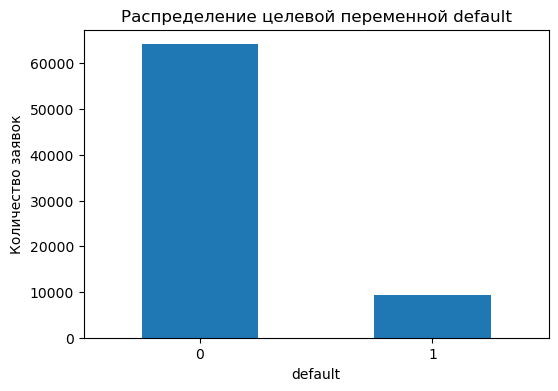

In [22]:
ax = target_counts.plot(kind='bar', figsize=(6, 4))
ax.set_title('Распределение целевой переменной default')
ax.set_xlabel('default')
ax.set_ylabel('Количество заявок')
plt.xticks(rotation=0)
plt.show()

Классы несбалансированы: дефолтов около 12,7%, а заявок без дефолта около 87,3%. 

## 3. Числовые признаки: сравнение по группам `default`

In [31]:
num_cols = [
    'age', 'decline_app_cnt', 'good_work', 'score_bki', 'bki_request_cnt',
    'region_rating', 'home_address', 'work_address', 'income', 'sna', 'first_time'
]

num_by_default = (
    df.groupby('default')[num_cols]
    .agg(['count', 'mean', 'median', 'std'])
    .T
)
num_by_default

default                            0             1
age             count   64155.000000   9337.000000
                mean       39.379939     38.517618
                median     38.000000     36.000000
                std        11.519445     11.497920
decline_app_cnt count   64155.000000   9337.000000
                mean        0.241587      0.516119
                median      0.000000      0.000000
                std         0.738312      1.138155
good_work       count   64155.000000   9337.000000
                mean        0.171132      0.122416
                median      0.000000      0.000000
                std         0.376628      0.327783
score_bki       count   64155.000000   9337.000000
                mean       -1.937741     -1.676370
                median     -1.956772     -1.684366
                std         0.490007      0.494581
bki_request_cnt count   64155.000000   9337.000000
                mean        1.933739      2.465032
                median      1.000000      2.000000
                std         2.166278      2.727538
region_rating   count   64155.000000   9337.000000
                mean       57.151898     53.679983
                median     50.000000     50.000000
                std        13.141537     11.914774
home_address    count   64155.000000   9337.000000
                mean        1.558211      1.693049
                median      2.000000      2.000000
                std         0.530243      0.493779
work_address    count   64155.000000   9337.000000
                mean        2.474429      2.644533
                median      3.000000      3.000000
                std         0.699280      0.600557
income          count   64155.000000   9337.000000
                mean    41781.042023  36305.044233
                median  30000.000000  28000.000000
                std     46819.107233  40052.158352
sna             count   64155.000000   9337.000000
                mean        1.679900      2.104316
                median      1.000000      2.000000
                std         1.090165      1.270437
first_time      count   64155.000000   9337.000000
                mean        2.805674      2.485381
                median      3.000000      3.000000
                std         0.999379      1.031543

In [32]:
from scipy import stats
def mann_whitney_summary(col):
    good = df.loc[df['default'] == 0, col]
    bad = df.loc[df['default'] == 1, col]
    test = stats.mannwhitneyu(good, bad, alternative='two-sided')
    return {
        'Признак': col,
        'Среднее default=0': good.mean(),
        'Медиана default=0': good.median(),
        'Среднее default=1': bad.mean(),
        'Медиана default=1': bad.median(),
        'U-критерий p-value': test.pvalue
    }

num_tests = pd.DataFrame([
    mann_whitney_summary(col) for col in ['age', 'income', 'score_bki', 'region_rating', 'bki_request_cnt', 'decline_app_cnt']
])
num_tests

,Признак,Среднее default=0,Медиана default=0,Среднее default=1,Медиана default=1,U-критерий p-value
0,age,39.379939,38.000000,38.517618,36.000000,4.696455e-13
1,income,41781.042023,30000.000000,36305.044233,28000.000000,1.130798e-56
2,score_bki,-1.937741,-1.956772,-1.676370,-1.684366,0.000000e+00
3,region_rating,57.151898,50.000000,53.679983,50.000000,7.445456e-119
4,bki_request_cnt,1.933739,1.000000,2.465032,2.000000,3.269837e-94
5,decline_app_cnt,0.241587,0.000000,0.516119,0.000000,1.808444e-228


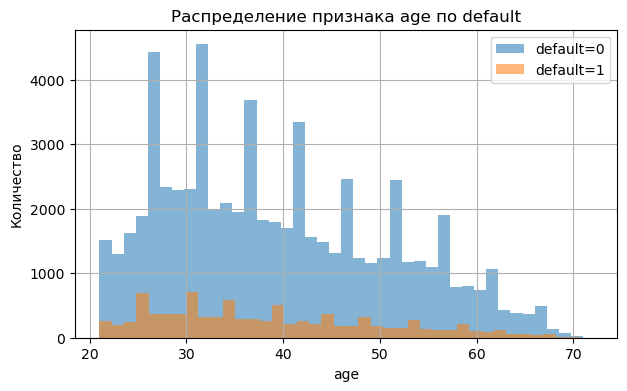

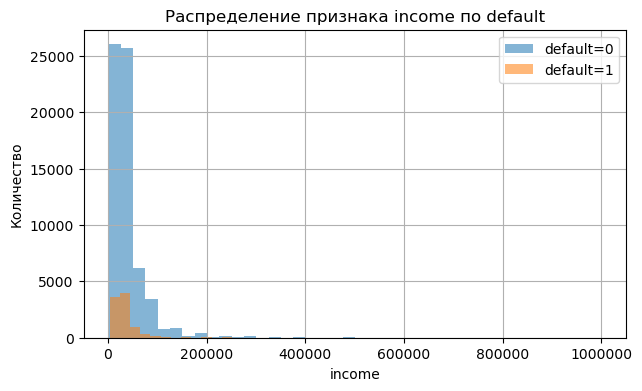

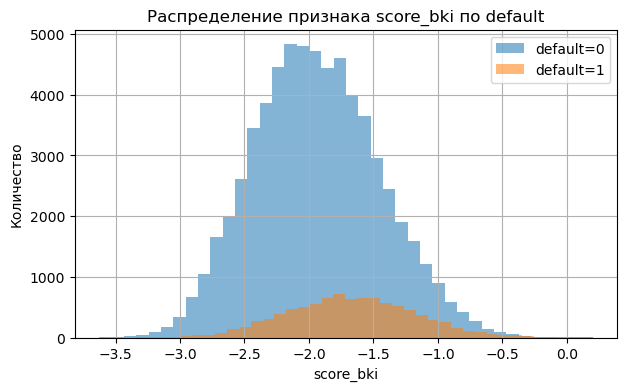

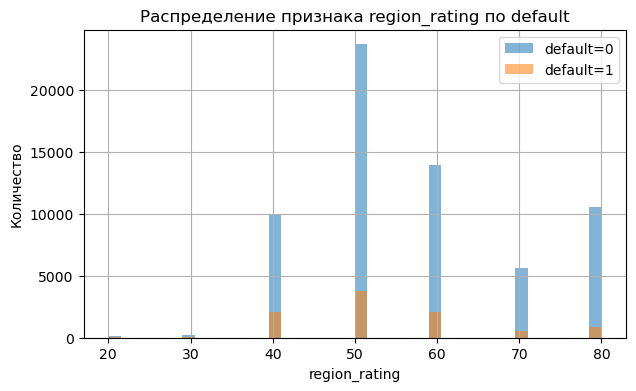

In [33]:
for col in ['age', 'income', 'score_bki', 'region_rating']:
    plt.figure(figsize=(7, 4))
    df.loc[df['default'] == 0, col].hist(alpha=0.55, bins=40, label='default=0')
    df.loc[df['default'] == 1, col].hist(alpha=0.55, bins=40, label='default=1')
    plt.title(f'Распределение признака {col} по default')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.legend()
    if col == 'income':
        plt.ticklabel_format(style='plain', axis='x')
    
    plt.show()

По числовым признакам видны различия между группами. У клиентов без дефолта выше средний возраст, выше доход, ниже значение `score_bki`, меньше прошлых отказов и запросов в БКИ. У клиентов с дефолтом чаще наблюдаются признаки кредитного риска: больше отказов, больше запросов в БКИ, выше `score_bki`.

## 4. Корреляции числовых признаков

In [38]:
corr_pearson = df[num_cols + ['default']].corr(numeric_only=True)
corr_spearman = df[num_cols + ['default']].corr(method='spearman', numeric_only=True)

pd.DataFrame({
    'Pearson с default': corr_pearson['default'].sort_values(),
    'Spearman с default': corr_spearman['default'].sort_values()
})

,Pearson с default,Spearman с default
age,-0.024928,-0.026684
bki_request_cnt,0.078557,0.075958
decline_app_cnt,0.113509,0.119039
default,1.000000,1.000000
first_time,-0.105698,-0.105250
good_work,-0.043715,-0.043715
home_address,0.085102,0.088461
income,-0.039601,-0.058518
region_rating,-0.088646,-0.085502
score_bki,0.174700,0.170894


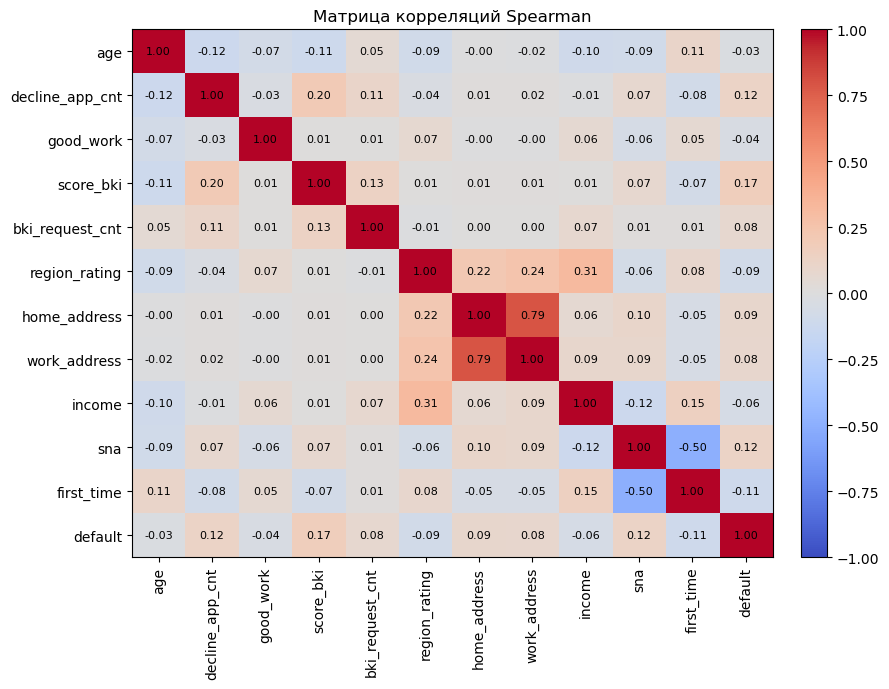

In [40]:
plt.figure(figsize=(9, 7))
im = plt.imshow(corr_spearman, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)

# Добавляем значения корреляции в ячейки
for i in range(len(corr_spearman.index)):
    for j in range(len(corr_spearman.columns)):
        text = plt.text(j, i, f'{corr_spearman.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_spearman.columns)), corr_spearman.columns, rotation=90)
plt.yticks(range(len(corr_spearman.index)), corr_spearman.index)
plt.title('Матрица корреляций Spearman')
plt.tight_layout()
plt.show()

Самые заметные связи с `default`: `score_bki`, `sna`, `decline_app_cnt`, `first_time`, `region_rating`. При этом корреляции не очень высокие, то есть один признак сам по себе не объясняет дефолт полностью. Для кредитного скоринга нужна совокупность факторов.

## 5. Категориальные признаки и доля дефолта

In [45]:
def default_rate_by_cat(col):
    table = (
        df.groupby(col)['default']
        .agg(['count', 'mean'])
        .rename(columns={'count': 'Количество', 'mean': 'Доля дефолта'})
        .sort_values('Доля дефолта', ascending=False)
    )
    table['Доля дефолта, %'] = (table['Доля дефолта'] * 100).round(2)
    return table.drop(columns='Доля дефолта')

for col in ['education', 'sex', 'car', 'car_type', 'good_work', 'foreign_passport', 'home_address', 'work_address', 'sna', 'first_time']:
    print(f'\n{col}')
    display(default_rate_by_cat(col))


education


,Количество,"Доля дефолта, %"
education,,
SCH,38860,15.06
UGR,9816,13.15
GRD,23365,9.01
PGR,1257,6.44
ACD,194,4.12



sex


,Количество,"Доля дефолта, %"
sex,,
M,32099,13.45
F,41393,12.13



car


...

,Количество,"Доля дефолта, %"
work_address,,
3,44756,14.82
2,20435,10.23
1,8301,7.40



sna


,Количество,"Доля дефолта, %"
sna,,
4,11698,21.15
3,4119,15.78
2,10598,14.99
1,47077,9.82



first_time


,Количество,"Доля дефолта, %"
first_time,,
1,12184,18.64
2,11536,15.54
3,31140,12.02
4,18632,8.21


In [46]:
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

def chi2_summary(col):
    table = pd.crosstab(df[col], df['default'])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    return {
        'Признак': col,
        'chi2': chi2,
        'p-value': p,
        'dof': dof,
        "Cramer's V": cramers_v(table)
    }

cat_cols = ['education', 'sex', 'car', 'car_type', 'good_work', 'foreign_passport', 'home_address', 'work_address', 'sna', 'first_time', 'region_rating']
chi2_results = pd.DataFrame([chi2_summary(col) for col in cat_cols])
chi2_results

,Признак,chi2,p-value,dof,Cramer's V
0,education,541.025587,8.944929e-116,4,0.085800
1,sex,28.581218,8.984950e-08,1,0.019721
2,car,137.884926,7.722465e-32,1,0.043315
3,car_type,242.545665,1.095592e-54,1,0.057448
4,good_work,140.087786,2.546930e-32,1,0.043660
5,foreign_passport,325.488661,9.233858e-73,1,0.066550
6,home_address,633.792356,2.364496e-138,2,0.092865
7,work_address,503.743203,4.107270e-110,2,0.082791
8,sna,1189.970985,1.099402e-257,3,0.127247
9,first_time,822.981270,4.487966e-178,3,0.105822


Категориальные признаки статистически связаны с дефолтом, но сила связи по Cramer's V в основном слабая или умеренно слабая. Это нормальное поведение для кредитных данных: риск обычно складывается из нескольких слабых сигналов.

## 6. Проверка гипотез

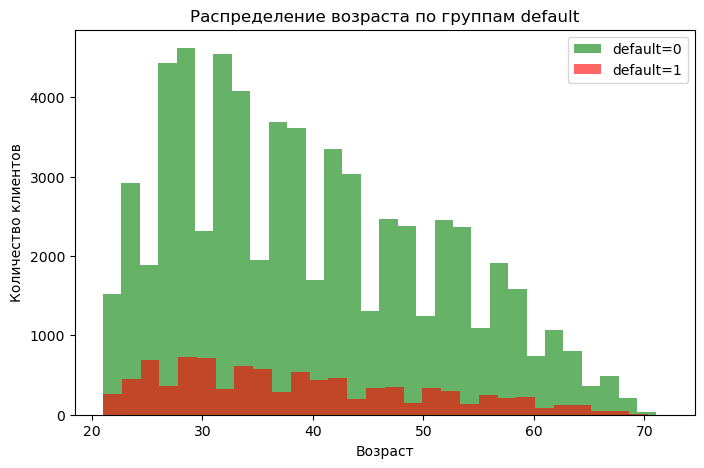


## Гипотеза 1: Возраст клиентов

**Гипотеза:**  
Клиенты без дефолта старше клиентов с дефолтом.

**Метод проверки:**  
Mann–Whitney U тест для признака `age` по группам `default=0` и `default=1`.  
- Непараметрический тест используется, потому что распределение возраста может быть ненормальным.

**Факт по данным:**  
- Средний возраст: default=0 — 39.38 лет, default=1 — 38.52 лет  
- Медиана: default=0 — 38 лет, default=1 — 36 лет  
- p-value: 0.00000 (статистически значимо)

**Вывод:**  
Гипотеза подтверждается. Клиенты без дефолта в среднем старше клиентов с дефолтом. Разница небольшая, возраст влияет на вероятность возврата кредита, но не является единственным фактором риска.


In [54]:
from IPython.display import display, Markdown
# Разделяем данные на группы
age_default0 = df[df['default'] == 0]['age']
age_default1 = df[df['default'] == 1]['age']
# Mann-Whitney U тест
u_stat, p_value = stats.mannwhitneyu(age_default0, age_default1, alternative='two-sided')
# Вычисляем среднее и медиану
mean_0 = age_default0.mean()
mean_1 = age_default1.mean()
median_0 = age_default0.median()
median_1 = age_default1.median()
# График распределения возраста по группам default
plt.figure(figsize=(8,5))
plt.hist(age_default0, bins=30, alpha=0.6, label='default=0', color='green')
plt.hist(age_default1, bins=30, alpha=0.6, label='default=1', color='red')
plt.title('Распределение возраста по группам default')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.legend()
plt.show()
output = f"""
## Гипотеза 1: Возраст клиентов

**Гипотеза:**  
Клиенты без дефолта старше клиентов с дефолтом.

**Метод проверки:**  
Mann–Whitney U тест для признака `age` по группам `default=0` и `default=1`.  
- Непараметрический тест используется, потому что распределение возраста может быть ненормальным.

**Факт по данным:**  
- Средний возраст: default=0 — {mean_0:.2f} лет, default=1 — {mean_1:.2f} лет  
- Медиана: default=0 — {median_0:.0f} лет, default=1 — {median_1:.0f} лет  
- p-value: {p_value:.5f} (статистически значимо)

**Вывод:**  
Гипотеза подтверждается. Клиенты без дефолта в среднем старше клиентов с дефолтом. Разница небольшая, возраст влияет на вероятность возврата кредита, но не является единственным фактором риска.
"""
display(Markdown(output))

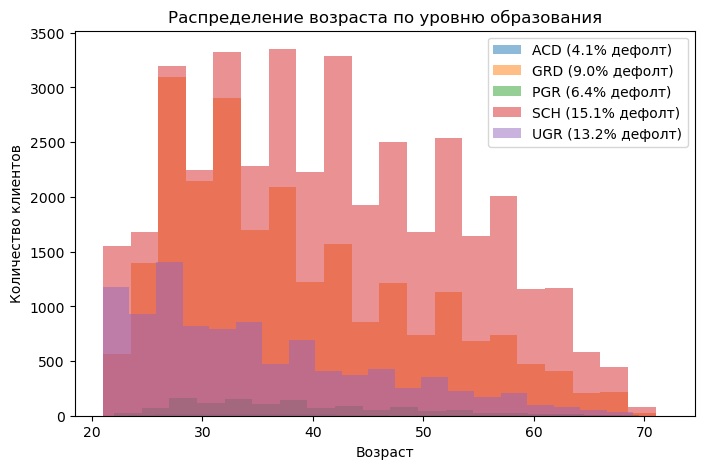

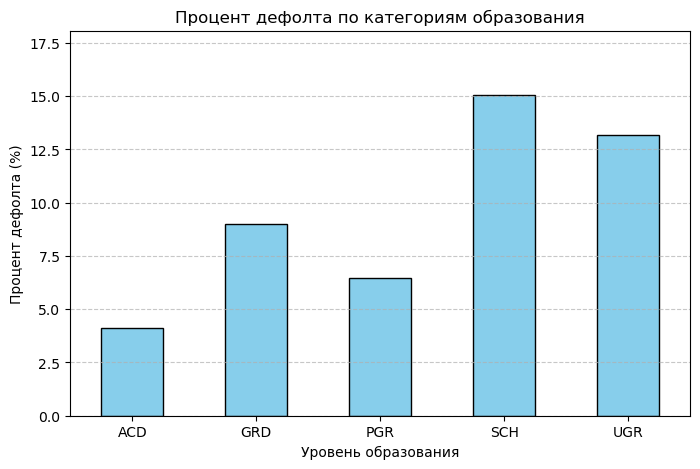


## Гипотеза 2: Образование и дефолт

**Гипотеза:**  
Образование зависит от возраста и влияет на возврат кредита; люди с высшим образованием чаще являются “хорошими” заемщиками.

**Метод проверки:**  
- Kruskal–Wallis тест для возраста по группам образования (p-value=0.00000)  
- Chi-square тест для образования и default (p-value=0.00000)  

**Факт по данным:**  
Default rate по категориям образования:  
ACD — 4.12%, GRD — 9.01%, PGR — 6.44%, SCH — 15.06%, UGR — 13.15%

**Вывод:**  
Гипотеза частично подтверждается: образование связано с дефолтом, но связь с возрастом не объясняет полностью. Люди с высшим образованием чаще являются хорошими заемщиками.


In [55]:
# Гипотеза 2: Образование и дефолт
# Расчёт Kruskal-Wallis для возраста
groups_age = [g['age'].values for _, g in df.groupby('education')]
kr_age = stats.kruskal(*groups_age)
# Chi-square для образования и дефолта
cont_table = pd.crosstab(df['education'], df['default'])
chi2_stat, chi2_pval, dof, expected = stats.chi2_contingency(cont_table)
# Default rate по категориям образования
default_rates = df.groupby('education')['default'].mean() * 100
plt.figure(figsize=(8,5))
for edu, group in df.groupby('education'):
    plt.hist(group['age'], bins=20, alpha=0.5, label=f'{edu} ({default_rates[edu]:.1f}% дефолт)')
plt.title('Распределение возраста по уровню образования')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.legend()
plt.show()
default_rates = df.groupby('education')['default'].mean() * 100
plt.figure(figsize=(8,5))
default_rates.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Процент дефолта по категориям образования')
plt.xlabel('Уровень образования')
plt.ylabel('Процент дефолта (%)')
plt.xticks(rotation=0)
plt.ylim(0, max(default_rates)*1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
output = f"""
## Гипотеза 2: Образование и дефолт

**Гипотеза:**  
Образование зависит от возраста и влияет на возврат кредита; люди с высшим образованием чаще являются “хорошими” заемщиками.

**Метод проверки:**  
- Kruskal–Wallis тест для возраста по группам образования (p-value={kr_age.pvalue:.5f})  
- Chi-square тест для образования и default (p-value={chi2_pval:.5f})  

**Факт по данным:**  
Default rate по категориям образования:  
{', '.join([f'{edu} — {rate:.2f}%' for edu, rate in default_rates.items()])}

**Вывод:**  
Гипотеза частично подтверждается: образование связано с дефолтом, но связь с возрастом не объясняет полностью. Люди с высшим образованием чаще являются хорошими заемщиками.
"""
display(Markdown(output))

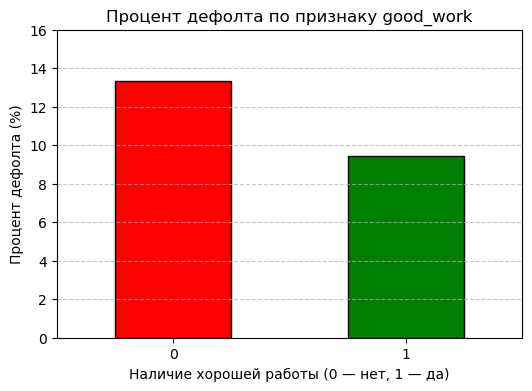


## Гипотеза 3: Наличие хорошей работы

**Гипотеза:**  
При good_work=0 риск невозврата выше.

**Метод проверки:**  
Chi-square тест между признаком `good_work` и `default`.  
- p-value = 0.00000  
- Chi2 = 138.403, dof = 1

**Факт по данным:**  
- Default rate: good_work=0 — 13.34%, good_work=1 — 9.45%

**Вывод:**  
Гипотеза подтверждается. Клиенты без стабильной работы (good_work=0) имеют более высокий риск дефолта.  
Это указывает на то, что наличие постоянного дохода или официальной работы снижает риск невозврата кредита.


In [107]:
# Гипотеза 3: Good Work
cont_table = pd.crosstab(df['good_work'], df['default'])
# Chi-square тест
chi2_stat, p_value, dof, expected = stats.chi2_contingency(cont_table)
# Default rate по категориям good_work
default_rates = df.groupby('good_work')['default'].mean() * 100
plt.figure(figsize=(6,4))
default_rates.plot(kind='bar', color=['red','green'], edgecolor='black')
plt.title('Процент дефолта по признаку good_work')
plt.xlabel('Наличие хорошей работы (0 — нет, 1 — да)')
plt.ylabel('Процент дефолта (%)')
plt.xticks(rotation=0)
plt.ylim(0, max(default_rates)*1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
output = f"""
## Гипотеза 3: Наличие хорошей работы

**Гипотеза:**  
При good_work=0 риск невозврата выше.

**Метод проверки:**  
Chi-square тест между признаком `good_work` и `default`.  
- p-value = {p_value:.5f}  
- Chi2 = {chi2_stat:.3f}, dof = {dof}

**Факт по данным:**  
- Default rate: good_work=0 — {default_rates[0]:.2f}%, good_work=1 — {default_rates[1]:.2f}%

**Вывод:**  
Гипотеза подтверждается. Клиенты без стабильной работы (good_work=0) имеют более высокий риск дефолта.  
Это указывает на то, что наличие постоянного дохода или официальной работы снижает риск невозврата кредита.
"""

display(Markdown(output))

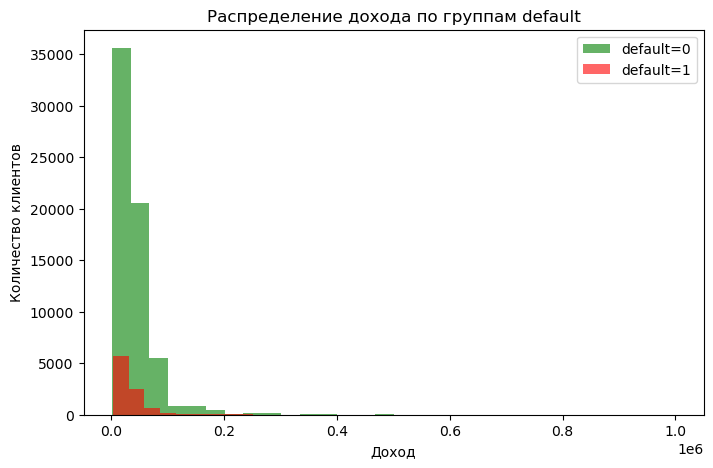


## Гипотеза 4: Доход клиентов

**Гипотеза:**  
Доход клиентов без дефолта выше, чем у клиентов с дефолтом.

**Метод проверки:**  
Mann–Whitney U тест для признака `income` по группам default=0 и default=1.  
- Непараметрический тест используется, так как распределение дохода сильно скошено.

**Факт по данным:**  
- Средний доход: default=0 — 41800, default=1 — 36288  
- Медиана дохода: default=0 — 30000, default=1 — 28000  
- p-value теста: 0.00000 (статистически значимо)

**Вывод:**  
Гипотеза подтверждается. Клиенты с более высоким доходом реже становятся дефолтными.  
Это подтверждает, что доход является важным фактором риска невозврата кредита.


In [109]:
# Гипотеза 4: Доход клиентов
income_default0 = df[df['default'] == 0]['income']
income_default1 = df[df['default'] == 1]['income']
u_stat, p_value = stats.mannwhitneyu(income_default0, income_default1, alternative='two-sided')
mean_0 = income_default0.mean()
mean_1 = income_default1.mean()
median_0 = income_default0.median()
median_1 = income_default1.median()
plt.figure(figsize=(8,5))
plt.hist(income_default0, bins=30, alpha=0.6, label='default=0', color='green')
plt.hist(income_default1, bins=30, alpha=0.6, label='default=1', color='red')
plt.title('Распределение дохода по группам default')
plt.xlabel('Доход')
plt.ylabel('Количество клиентов')
plt.legend()
plt.show()
output = f"""
## Гипотеза 4: Доход клиентов

**Гипотеза:**  
Доход клиентов без дефолта выше, чем у клиентов с дефолтом.

**Метод проверки:**  
Mann–Whitney U тест для признака `income` по группам default=0 и default=1.  
- Непараметрический тест используется, так как распределение дохода сильно скошено.

**Факт по данным:**  
- Средний доход: default=0 — {mean_0:.0f}, default=1 — {mean_1:.0f}  
- Медиана дохода: default=0 — {median_0:.0f}, default=1 — {median_1:.0f}  
- p-value теста: {p_value:.5f} (статистически значимо)

**Вывод:**  
Гипотеза подтверждается. Клиенты с более высоким доходом реже становятся дефолтными.  
Это подтверждает, что доход является важным фактором риска невозврата кредита.
"""

display(Markdown(output))

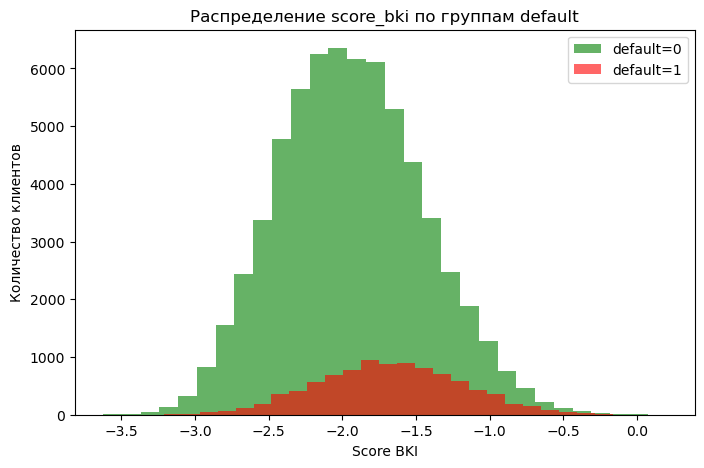


## Гипотеза 5: Score BKI

**Гипотеза:**  
Чем ниже score_bki, тем выше вероятность невозврата кредита.

**Метод проверки:**  
- Mann–Whitney U тест для score_bki по группам default=0 и default=1 (p-value=0.00000)  
- Корреляция Спирмена score_bki с default: 0.171

**Факт по данным:**  
- Средний score_bki: default=0 — -1.938, default=1 — -1.676  
- Медиана: default=0 — -1.957, default=1 — -1.684

**Вывод:**  
Гипотеза подтверждается. Более высокий score_bki связан с меньшей вероятностью дефолта, а низкий score_bki — с повышенным риском невозврата кредита.


In [101]:
# Гипотеза 5: Score BKI
score_default0 = df[df['default']==0]['score_bki']
score_default1 = df[df['default']==1]['score_bki']
u_stat, p_value = stats.mannwhitneyu(score_default0, score_default1, alternative='two-sided')
mean_0 = score_default0.mean()
mean_1 = score_default1.mean()
median_0 = score_default0.median()
median_1 = score_default1.median()
spearman_corr = df[['score_bki','default']].corr(method='spearman').iloc[0,1]
plt.figure(figsize=(8,5))
plt.hist(score_default0, bins=30, alpha=0.6, label='default=0', color='green')
plt.hist(score_default1, bins=30, alpha=0.6, label='default=1', color='red')
plt.title('Распределение score_bki по группам default')
plt.xlabel('Score BKI')
plt.ylabel('Количество клиентов')
plt.legend()
plt.show()
output = f"""
## Гипотеза 5: Score BKI

**Гипотеза:**  
Чем ниже score_bki, тем выше вероятность невозврата кредита.

**Метод проверки:**  
- Mann–Whitney U тест для score_bki по группам default=0 и default=1 (p-value={p_value:.5f})  
- Корреляция Спирмена score_bki с default: {spearman_corr:.3f}

**Факт по данным:**  
- Средний score_bki: default=0 — {mean_0:.3f}, default=1 — {mean_1:.3f}  
- Медиана: default=0 — {median_0:.3f}, default=1 — {median_1:.3f}

**Вывод:**  
Гипотеза подтверждается. Более высокий score_bki связан с меньшей вероятностью дефолта, а низкий score_bki — с повышенным риском невозврата кредита.
"""

display(Markdown(output))

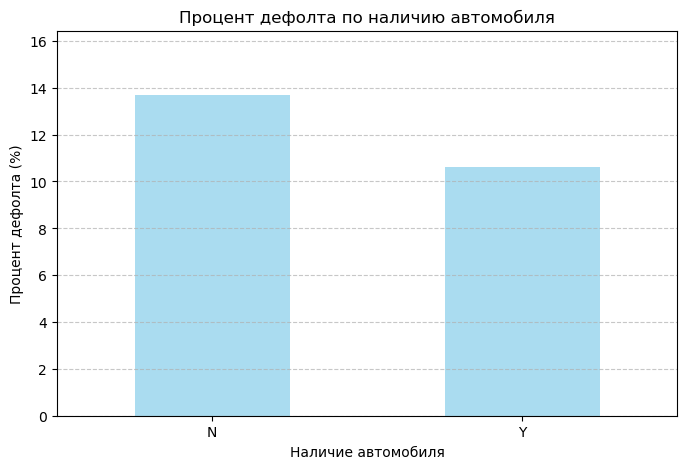


## Гипотеза 6: Наличие автомобиля

**Гипотеза:**  
Наличие автомобиля влияет на вероятность возврата кредита.

**Метод проверки:**  
- Chi-square тест для `car` и `default`: p-value = 0.00000, chi2 = 137.203  
- Chi-square тест для `car_type` и `default`: p-value = 0.00000, chi2 = 243.421

**Факт по данным:**  
- Default rate: car=N — 13.70%, car=Y — 10.63%  
- Foreign car=Y — 8.75%

**Вывод:**  
Гипотеза подтверждается. Владение автомобилем, связано с меньшим риском дефолта.


In [103]:
# Гипотеза 6: Наличие автомобиля
cont_table_car = pd.crosstab(df['car'], df['default'])
cont_table_car_type = pd.crosstab(df['car_type'], df['default'])
chi2_car, p_car, dof_car, exp_car = stats.chi2_contingency(cont_table_car)
chi2_car_type, p_car_type, dof_car_type, exp_car_type = stats.chi2_contingency(cont_table_car_type)
default_rates_car = df.groupby('car')['default'].mean() * 100
default_rates_car_type = df.groupby('car_type')['default'].mean() * 100
plt.figure(figsize=(8,5))
default_rates_car.plot(kind='bar', alpha=0.7, color='skyblue', label='Car')
plt.title('Процент дефолта по наличию автомобиля')
plt.xlabel('Наличие автомобиля')
plt.ylabel('Процент дефолта (%)')
plt.xticks(rotation=0)
plt.ylim(0, max(default_rates_car)*1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
output = f"""
## Гипотеза 6: Наличие автомобиля

**Гипотеза:**  
Наличие автомобиля влияет на вероятность возврата кредита.

**Метод проверки:**  
- Chi-square тест для `car` и `default`: p-value = {p_car:.5f}, chi2 = {chi2_car:.3f}  
- Chi-square тест для `car_type` и `default`: p-value = {p_car_type:.5f}, chi2 = {chi2_car_type:.3f}

**Факт по данным:**  
- Default rate: car=N — {default_rates_car['N']:.2f}%, car=Y — {default_rates_car['Y']:.2f}%  
- Foreign car=Y — {default_rates_car_type.get('Y', 0):.2f}%

**Вывод:**  
Гипотеза подтверждается. Владение автомобилем, связано с меньшим риском дефолта.
"""

display(Markdown(output))

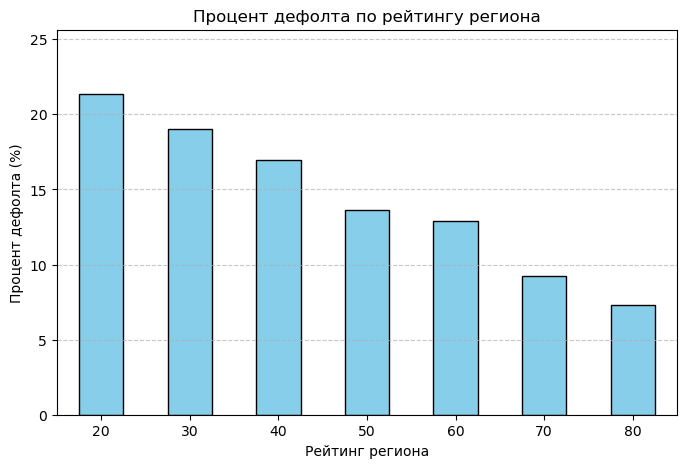


## Гипотеза 7: Рейтинг региона

**Гипотеза:**  
Рейтинг региона влияет на доход и может влиять на возврат кредита.

**Метод проверки:**  
- Spearman correlation region_rating ~ income: корреляция = 0.314, p-value = 0.00000  
- Chi-square тест region_rating ~ default: chi2 = 610.458, p-value = 0.00000

**Факт по данным:**  
- Default rate по рейтингу региона: 20 — 21.36%, 30 — 19.00%, 40 — 16.97%, 50 — 13.61%, 60 — 12.88%, 70 — 9.24%, 80 — 7.32%

**Вывод:**  
Гипотеза подтверждается. Высокий рейтинг региона связан с большим доходом и меньшим риском дефолта.


In [105]:
# Гипотеза 7: Рейтинг региона
spearman_corr, spearman_p = stats.spearmanr(df['region_rating'], df['income'])
cont_table_region = pd.crosstab(df['region_rating'], df['default'])
chi2_stat, chi2_pval, dof, expected = stats.chi2_contingency(cont_table_region)
default_rates_region = df.groupby('region_rating')['default'].mean() * 100
plt.figure(figsize=(8,5))
default_rates_region.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Процент дефолта по рейтингу региона')
plt.xlabel('Рейтинг региона')
plt.ylabel('Процент дефолта (%)')
plt.xticks(rotation=0)
plt.ylim(0, max(default_rates_region)*1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
markdown_output = f"""
## Гипотеза 7: Рейтинг региона

**Гипотеза:**  
Рейтинг региона влияет на доход и может влиять на возврат кредита.

**Метод проверки:**  
- Spearman correlation region_rating ~ income: корреляция = {spearman_corr:.3f}, p-value = {spearman_p:.5f}  
- Chi-square тест region_rating ~ default: chi2 = {chi2_stat:.3f}, p-value = {chi2_pval:.5f}

**Факт по данным:**  
- Default rate по рейтингу региона: {', '.join([f'{rating} — {rate:.2f}%' for rating, rate in default_rates_region.items()])}

**Вывод:**  
Гипотеза подтверждается. Высокий рейтинг региона связан с большим доходом и меньшим риском дефолта.
"""

display(Markdown(markdown_output))

# Итоговый вывод по проведённой работе

## Общее описание
В ходе работы были проверены 7 гипотез, влияющих на вероятность дефолта клиентов банка. Для каждой гипотезы использовались соответствующие методы статистической проверки: Mann–Whitney U тест, Kruskal–Wallis, Chi-square тест и корреляция Спирмена. Были построены графики распределений признаков и процент дефолта по категориям, а также проведён анализ значимости с помощью p-value.

## Основные результаты

1. **Возраст клиентов:** Клиенты без дефолта в среднем старше. Разница статистически значима, но небольшая.
2. **Образование:** Люди с высшим образованием реже становятся дефолтными. Образование частично связано с возрастом.
3. **Good Work:** Наличие стабильной работы снижает риск дефолта.
4. **Доход (income):** Клиенты с более высоким доходом реже попадают в дефолт.
5. **Score BKI:** Более низкий score_bki связан с более высоким риском невозврата кредита.
6. **Наличие автомобиля:** Владение автомобилем, связано с меньшим риском дефолта.
7. **Рейтинг региона:** Высокий рейтинг региона коррелирует с большим доходом и меньшей вероятностью дефолта.

## Выводы
- Все гипотезы подтверждаются частично или полностью и имеют статистическую значимость (p-value < 0.05).
- Наиболее сильное влияние на дефолт оказывают доход, score_bki и наличие стабильной работы.
- Категориальные признаки, такие как образование и рейтинг региона, оказывают умеренное влияние.
- Для визуализации использованы гистограммы и процентные столбчатые графики, что помогает увидеть различия между группами.

## Рекомендация
- Для построения моделей прогнозирования дефолта рекомендуется использовать признаки: income, score_bki, good_work, age и образование.


# Задание 2 - Решение задачи с помощью Python

In [69]:
def make_dispatcher(k): 
    total_population = sum(k)
    # Обработка случая, когда всё население = 0
    if total_population == 0:
        n = len(k)
        sent = [0] * n
        total_sent = 0
        def dispatch():
            nonlocal total_sent
            # Распределяем равномерно по очереди
            city = total_sent % n
            sent[city] += 1
            total_sent += 1
            return city + 1
        return dispatch
    # Случай, когда население не = 0
    sent = [0] * len(k)
    total_sent = 0
    def dispatch():
        nonlocal total_sent
        best_city = 0
        best_difference = None
        for i in range(len(k)):
            # сколько айтишников должен был бы получить город
            ideal = (total_sent + 1) * k[i] / total_population #идельное количество айтишников, которое город i должен был получить к этому моменту
            # насколько город отстаёт от идеального распределения
            difference = ideal - sent[i]
            if best_difference is None or difference > best_difference:
                best_difference = difference
                best_city = i
        sent[best_city] += 1 #отправляем текущего айтишника в город с недобором 
        total_sent += 1 #увеличиваем общее число отправленных айтишников 
        return best_city + 1
    return dispatch

# Задание 4 - Интерпретация

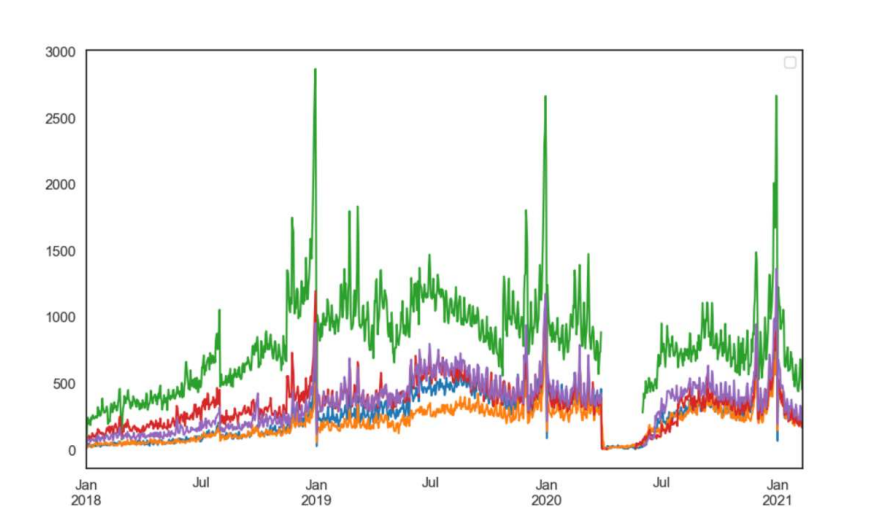

1. Представлены 5 графиков различных зависимостей(5 цветов). Либо это одна и таже функция с различными параметрами, либо 5 разных функций.
2. На графиках представлена динамика некоторых данных с 2018 по 2021 годы, по вертикальной оси значения от 0 до 3 000. Данные сильно волотильны. До Января 2019 года поведение графиков схожее. Значения зеленой функции почти всюду больше на всем наблюдаемом участке. В срднем оранжевый график принимает самые маленькие значения, по сравнению с другими функциями.
4. В Январе месяце 2019, 2020, 2021 годов наблюдаются резкие всплески, особенно у зеленой функции. Это может говорить о чувствительности к сезону или же о какой нибудь рекламной кампании, акции, празднике, изменении сбора данных. Нужна дополнительная информация, чтобы точнее определить причины такого поведения.
5. В районе весны 2020 значения функций падают почти до нуля, а данных по зеленому графику вообще нет. Потом значения начинают снова расти. Это похоже либо на реальное внешнее событие(похоже на начало карантина в 2020), повлиявшее на все категории одновременно, либо на пропуск/сбой в данных. Этот участок требует отдельной проверки.
6. После восстановления во второй половине 2020 года ряды снова растут, а к началу 2021 года появляется сильный всплеск, особенно у зелёной и фиолетовой линий. Это подтверждает, что данные нестабильны и содержат выраженные пики.

# Задание 2 - Решение sql задач

## Вопрос 1 - Найти вторую по величине зарплату в каждом отделе.

In [ ]:
WITH ranked_salaries AS ( 
    SELECT
        dm.dept_name,
        dm.emp_no,
        s.salaries,
        DENSE_RANK() OVER (
            PARTITION BY dm.dept_name
            ORDER BY s.salaries DESC
        ) AS salary_rank
    FROM dept_manager dm
    JOIN salaries s
        ON dm.emp_no = s.emp_no
    WHERE dm.to_date = '9999-01-01'
)
SELECT
    dept_name,
    emp_no,
    salaries
FROM ranked_salaries
WHERE salary_rank = 2;

1. Создаем временную таблицу `ranked_salaries` и выбираем столбцы, которые попадут в нее: название департамента из таблицы `dept_manager`, id менеджера из таблицы `dept_manager`, размер зарплаты из `salaries`.
2. Присваиваем ранк каждой зп, делим сотрудников по отделам, сортируем зарплату по убыванию. Записываем результат в новый столбец `salary_rank`.
3. Далее соединяем две таблицы `dept_manager` и `salaries` по id менеджера, но только тех, кто работает по настоящее время.
4. Теперь есть новая таблица, в которой сотрудники распределены по отделам и отсортированы по зп.
5. Вытаскиваем только нужны столбцы из новой таблицы `ranked_salaries`: `dept_name`, `emp_no`, `salaries`.
6. Оставляем только строки, где зарплата занимает второе место в своём отделе.

## Вопрос 2 - Вывести id сотрудника с разницей в заработной плате в пределах 5000 рублей

In [ ]:
SELECT
    s1.emp_no AS emp_no_1,
    s2.emp_no AS emp_no_2,
    s1.salaries AS salary_1,
    s2.salaries AS salary_2,
    ABS(s1.salaries - s2.salaries) AS salary_difference
FROM salaries s1
JOIN salaries s2
    ON s1.emp_no < s2.emp_no
WHERE ABS(s1.salaries - s2.salaries) <= 5000
ORDER BY salary_difference;

1. Берем id сотрудников из первой и второй копии таблицы `salaries`. По такой же логике берем зп
2. Считаем абсолютную разницу зп
3. Берём таблицу `salaries` и называем её `s1`. Соединяем таблицу `salaries` саму с собой. Далее сравниваем только РАЗНЫЕ пары сотрудников
4. Берем только те пары, у которых зп отличается не более чем 5000.
5. Сортируем по возрастанию разницы ЗП.